In [11]:
import pandas as pd # Manejo de datos
import numpy as np # Manejo de arreglos
import matplotlib.pyplot as plt # Graficas
from sklearn.model_selection import train_test_split # Dividir datos en entrenamiento y prueba
from sklearn.preprocessing import StandardScaler # Normalizar datos

In [12]:
data=pd.read_csv('../Database/1_diabetes_dataset.csv') # Cargar datos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

In [13]:
# null=data['y'].isnull() # Verificar valores nulos
# data['y']=data['y'].fillna(data['y'].median()) # Rellenar valores nulos con la media
# data.loc[null,'x']=data['x'].median() # Rellenar valores nulos con la media
x_train, x_test, y_train,y_test=train_test_split(data[['age']],data[['diabetes_risk_score']],test_size=0.2, shuffle=False) # Dividir datos en entrenamiento y prueba
x=x_train.values.flatten() # Convertir a arreglo 1D
y=y_train.values.flatten() # Convertir a arreglo 1D

In [14]:
scaler = StandardScaler() 
x_train_scaled = scaler.fit_transform(x.reshape(-1, 1)).flatten() # Normalizar datos de entrenamiento (x)

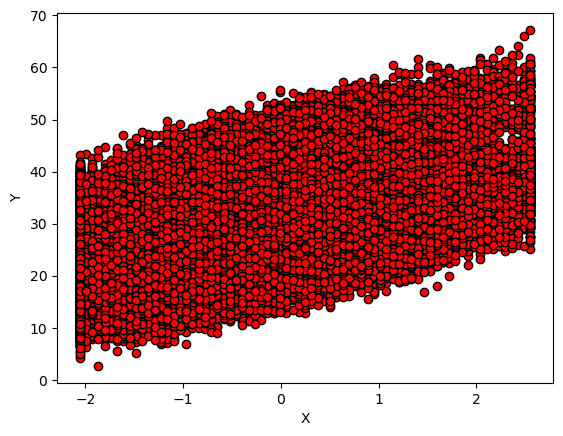

In [15]:

def plotData(x_train_scaled,y): # Graficar datos de entrenamiento
    fig=plt.figure() # crear figura
    plt.plot(x_train_scaled,y,'ro',mec='k')  # Grafica los datos de entrenamiento
    plt.xlabel('X') 
    plt.ylabel('Y')
plotData(x_train_scaled,y)

In [16]:
m=y.size # numero de ejemplos de entrenamiento
x = np.stack([np.ones(m), x_train_scaled], axis=1) # Agrega una columna de unos a X para el término de intersección

In [17]:
def calcularCosto(x,y,theta): # se recibe valores de theta generados por el descenso de gradiente
    m=y.size # numero de ejemplos de entrenamiento
    j=0
    j=(1/(2*m))*np.sum(np.square(np.dot(x,theta)-y)) # La hipotesis es la prediccion y se lo resta con el valor real para calcular errores
    return j # Valor del costo (error cuadrático medio)

In [18]:
def gradientDescent(x_train, y_train, theta, alpha, num_iters): 
    m = y_train.shape[0]  # numero de ejemplos de entrenamiento
    theta = theta.copy() # Evitar modificar theta fuera de la función
    J_history = [] # Lista para almacenar historial de costos 
    for i in range(num_iters): 
        theta = theta - (alpha / m) * (np.dot(x_train, theta) - y_train).dot(x_train) # Actualizar theta
        J_history.append(calcularCosto(x_train, y_train, theta)) # Guardar el costo en cada iteración
    return theta, J_history # Retorna los valores optimos de theta y el historial de costos

In [19]:
# inicializa los parametros de ajuste
theta = np.zeros(2) # Vector de parámetros: [theta0 (intercepto), theta1 (pendiente)]
iterations = 800 # Número de iteraciones para el entrenamiento
alpha = 0.01 # Tasa de aprendizaje (controla el tamaño del paso en cada iteración)

# Ejecutar algoritmo de descenso de gradiente para optimizar los parámetros
theta, J_history = gradientDescent(x ,y, theta, alpha, iterations)
print('Theta encontrada por descenso gradiente: {:.4f}, {:.4f}'.format(*theta))
print("Costo:", calcularCosto(x, y, theta))

Theta encontrada por descenso gradiente: 30.1997, 4.4933
Costo: 30.863814322582478


Text(0.5, 1.0, 'Convergencia del costo')

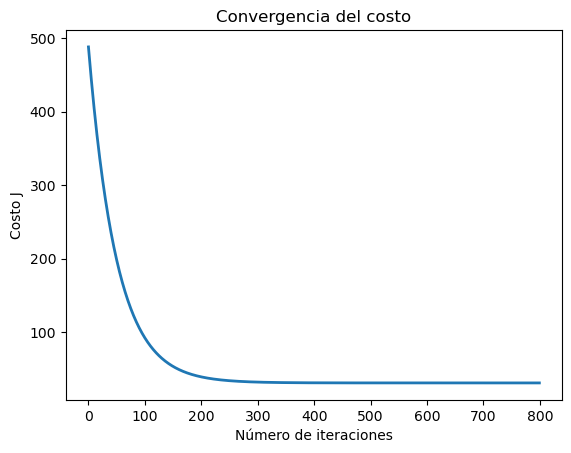

In [20]:
# Graficar la convergencia del costo
plt.plot(np.arange(len(J_history)), J_history, lw=2)
plt.xlabel('Número de iteraciones')
plt.ylabel('Costo J')
plt.title('Convergencia del costo')

Text(0.5, 1.0, 'Datos de entrenamiento y regresion lineal')

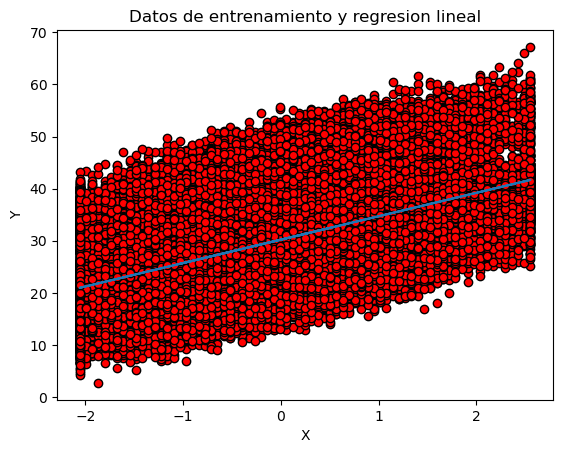

In [21]:
# Mostrar resultados de entrenamiento
plotData(x_train_scaled,y)
plt.plot(x_train_scaled, np.dot(x, theta), '-') # Graficar la linea de regresion
plt.title('Datos de entrenamiento y regresion lineal')

In [22]:
# Preprocesar y predecir con datos de prueba
x_test_scaled = scaler.transform(x_test.values).flatten() # Normalizar x de prueba
m_test = x_test_scaled.size # numero de ejemplos de prueba
x_test_pre = np.stack([np.ones(m_test), x_test_scaled], axis=1) # Agrega una columna de unos a (x) de prueba
y_pred = np.dot(x_test_pre, theta) # Predecir valores
# print("Predicciones:", y_pred)  
# Comparar con valores reales
# print("Valores reales:", y_test.values.flatten())   

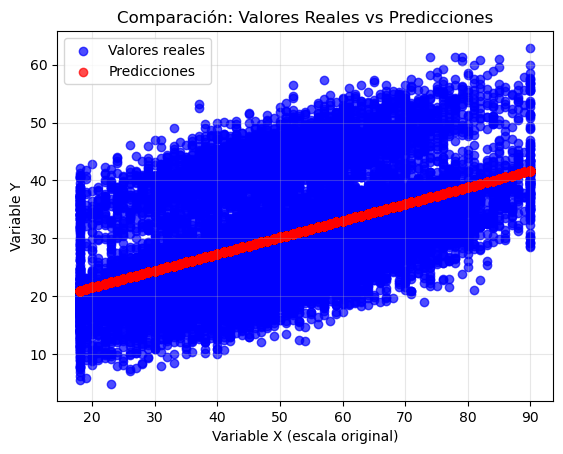

In [23]:
# Graficar valores reales
plt.scatter(x_test, y_test, color='blue', label='Valores reales', alpha=0.7)

# Graficar predicciones
plt.scatter(x_test, y_pred, color='red', label='Predicciones', alpha=0.7)
# Configuración del gráfico
plt.xlabel('Variable X (escala original)')
plt.ylabel('Variable Y')
plt.title('Comparación: Valores Reales vs Predicciones')
plt.legend()
plt.grid(True, alpha=0.3)